──────────────────────────────────────────────── Prediction Result ────────────────────────────────────────────────

                     Model Output for Entry 6                     
┏━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃    Label    ┃   Logit ┃ Confidence ┃ Prediction ┃ Ground Truth ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│  Effusion   │ -0.3685 │     0.4089 │          0 │            1 │
├─────────────┼─────────┼────────────┼────────────┼──────────────┤
│ Atelectasis │ -2.2059 │     0.0992 │          0 │            0 │
└─────────────┴─────────┴────────────┴────────────┴──────────────┘

────────────────────────────────────────────────── CSV Data Row ───────────────────────────────────────────────────

┏━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ IMGPATH  ┃ DISEASE… ┃ MULTIHOT ┃ FOLLOWUP ┃ PATID ┃ AGE ┃ GENDER ┃ VP ┃ LOGIT_E… ┃ LABEL_… ┃ LOGIT_A… ┃ LABEL_… ┃
┡━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ /home/m… │ ['Edema… │ [1, 0]   │ 6        │ 17138 │ 22  │ M      │ AP │ -0.3687… │ 1       │ -2.2052… │ 0       │
│          │ 'Effusi… │          │          │       │     │        │    │          │         │          │         │
└──────────┴──────────┴──────────┴──────────┴───────┴─────┴────────┴────┴──────────┴─────────┴──────────┴─────────┘

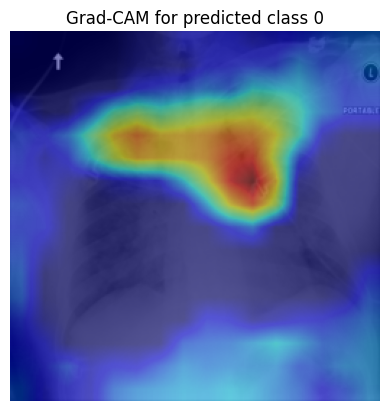

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rich.console import Console
from rich.table import Table
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

from CNN import InfernoCalibNet, ChestXRayDataset, OUT_DIR, CALIB_DIR

console = Console()

def runGradCAM(model: torch.nn.Module, input_tensor: torch.Tensor, device: torch.device):
    model.eval()
    target_layer = model.base_model[-1]

    cam = GradCAM(model=model, target_layers=[target_layer])
    input_tensor = input_tensor.unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    with torch.no_grad():
        output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()
    targets = [ClassifierOutputTarget(predicted_class)]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    grayscale_cam = np.maximum(grayscale_cam, 0)
    grayscale_cam = grayscale_cam - grayscale_cam.min()
    grayscale_cam = grayscale_cam / grayscale_cam.max()

    img = input_tensor.detach().cpu().squeeze().numpy()
    fig, ax = plt.subplots()
    ax.imshow(img, cmap="gray")
    ax.imshow(grayscale_cam, cmap="jet", alpha=0.5)
    ax.set_title(f"Grad-CAM for predicted class {predicted_class}")
    plt.axis("off")
    plt.show()

def predict_single_entry(index: int = 1000):
    torch.cuda.empty_cache()

    df = pd.read_csv(CALIB_DIR / "calibration_test.csv")
    row = df.iloc[index]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = InfernoCalibNet(num_classes=2).to(device)
    model.load_state_dict(torch.load(CALIB_DIR / "InfernoCalibNetML.pth", weights_only=True))
    model.eval()

    ds = ChestXRayDataset(CALIB_DIR / "calibration_test.csv", transform=False)
    image_tensor, target_tensor = ds[index]
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        output = model(image_tensor.unsqueeze(0))
        logits = output.cpu().squeeze()
        probs = torch.sigmoid(logits)
        predictions = (probs > 0.5).int()

    console.rule("[bold green]Prediction Result")
    table = Table(title=f"Model Output for Entry {index}", show_lines=True)
    table.add_column("Label", justify="center")
    table.add_column("Logit", justify="right")
    table.add_column("Confidence", justify="right")
    table.add_column("Prediction", justify="right")
    table.add_column("Ground Truth", justify="right")

    for label, logit, prob, pred_val, true_val in zip(
        ["Effusion", "Atelectasis"], logits.numpy(), probs.numpy(), predictions.numpy(), target_tensor.numpy()
    ):
        table.add_row(label, f"{logit:.4f}", f"{prob:.4f}", str(int(pred_val)), str(int(true_val)))

    console.print(table)

    console.rule("[bold cyan]CSV Data Row")
    csv_table = Table(show_header=True, header_style="bold cyan")
    for col in row.index:
        csv_table.add_column(col)
    csv_table.add_row(*[str(row[col]) for col in row.index])
    console.print(csv_table)

    runGradCAM(model, image_tensor, device)

    # return logits.numpy(), probs.numpy(), predictions.numpy(), target_tensor.numpy()

predict_single_entry(index=6)

